# Part 3 — Decision: does any (metric, weight) beat the baseline on both axes?

Applies `methodology.md` §3's decision criterion to the sweep characterized in `part_1`
(prediction) and `part_2` (latent geometry): for each `(penalty_metric, weight)` cell,

- **primary criterion**: `average_precision` (fair scope, test split, mean over 5
  repetitions) higher than the baseline's;
- **sanity condition**: `effective_rank` (test, mean over 5 repetitions) not lower than
  baseline, **and** `cloud_asymmetry` (test, mean over 5 repetitions) not higher than
  baseline — i.e. the collapse `methodology.md` set out to fix is not still there or worse.

A cell passing both is a **winner candidate**; among winner candidates, the one with the
highest `average_precision` becomes the base combination for later head-loss comparisons
(`methodology.md` §3, last paragraph). If no cell passes both, the base combination stays
the no-contractive baseline, and the result is reported as negative.

**No file handoff**: this notebook does not read CSVs. `PREDICTION_SUMMARY` and
`GEOMETRY_SUMMARY` below are the small per-cell mean dicts printed at the end of `part_1`
and `part_2` respectively (12 cells x 1-2 numbers each) — copy those two `print(...)`
outputs in verbatim after re-running either notebook. Baseline is `bce-baseline-20260905-01`,
same split as the sweep (verified in `part_1`'s introduction).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from msi_autoencoder_wrapper.visualization import resolve_theme

PENALTY_METRICS = ["frobenius", "spectral", "hinged"]
WEIGHTS = [1e-5, 1e-4, 1e-3, 1e-2]

theme = resolve_theme(None)
theme.apply()
METRIC_COLOR = {metric: theme.color_for_model(metric, index) for index, metric in enumerate(PENALTY_METRICS)}

## Inputs — pasted from `part_1`'s and `part_2`'s `print(...)` output

Replace these two literals whenever `part_1`/`part_2` are re-run (e.g. after a metric
implementation change, or a wider weight sweep).

In [2]:
# Pasted verbatim from part_1_prediction_metric_weight_sweep.ipynb's "Summary for part_3" cell.
PREDICTION_SUMMARY = {'baseline_average_precision': 0.7756193632234789, 'cells': {('frobenius', 1e-05): 0.7665166177633103, ('frobenius', 0.0001): 0.7413475886904133, ('frobenius', 0.001): 0.6838660648894102, ('frobenius', 0.01): 0.568325533285319, ('spectral', 1e-05): 0.7809281460669676, ('spectral', 0.0001): 0.7692858142089879, ('spectral', 0.001): 0.6908227301285522, ('spectral', 0.01): 0.6132124546979265, ('hinged', 1e-05): 0.7726352524226876, ('hinged', 0.0001): 0.7658902378458156, ('hinged', 0.001): 0.7709595919208562, ('hinged', 0.01): 0.7754510751320514}}

# Pasted verbatim from part_2_latent_geometry_metric_weight_sweep.ipynb's "Summary for part_3" cell.
GEOMETRY_SUMMARY = {'baseline_effective_rank': 4.707791385581245, 'baseline_cloud_asymmetry': 0.4942499589207867, 'cells': {('frobenius', 1e-05): {'effective_rank': 4.622549921352927, 'cloud_asymmetry': 0.724697453072117}, ('frobenius', 0.0001): {'effective_rank': 4.593320011943366, 'cloud_asymmetry': 0.8940550515441152}, ('frobenius', 0.001): {'effective_rank': 4.592690195154901, 'cloud_asymmetry': 0.9656131316304977}, ('frobenius', 0.01): {'effective_rank': 4.726261591900529, 'cloud_asymmetry': 0.9899420484737738}, ('spectral', 1e-05): {'effective_rank': 4.696726955829785, 'cloud_asymmetry': 0.4961270093326826}, ('spectral', 0.0001): {'effective_rank': 4.816737937666808, 'cloud_asymmetry': 0.5837586284824954}, ('spectral', 0.001): {'effective_rank': 4.919403418995654, 'cloud_asymmetry': 0.7191693766993806}, ('spectral', 0.01): {'effective_rank': 4.868267258112498, 'cloud_asymmetry': 0.8639544751232071}, ('hinged', 1e-05): {'effective_rank': 4.725250913016749, 'cloud_asymmetry': 0.5530182022237092}, ('hinged', 0.0001): {'effective_rank': 4.618558333077503, 'cloud_asymmetry': 0.5742725912728222}, ('hinged', 0.001): {'effective_rank': 4.658163766268986, 'cloud_asymmetry': 0.5943013852276546}, ('hinged', 0.01): {'effective_rank': 4.659659723881363, 'cloud_asymmetry': 0.6168773209222227}}}

## Decision table

### Methodology
#### Theoretical
- `methodology.md` §3's two-part criterion, evaluated per `(penalty_metric, weight)` cell
  using the 5-repetition mean of each quantity (not a single repetition), against the
  5-repetition baseline mean.

#### Implementation
- `average_precision_gain = cell_average_precision - baseline_average_precision`;
  `effective_rank_ok = cell_effective_rank >= baseline_effective_rank`;
  `cloud_asymmetry_ok = cell_cloud_asymmetry <= baseline_cloud_asymmetry`;
  `winner_candidate = (average_precision_gain > 0) & effective_rank_ok & cloud_asymmetry_ok`.

### Notes

In [3]:
baseline_average_precision = PREDICTION_SUMMARY["baseline_average_precision"]
baseline_effective_rank = GEOMETRY_SUMMARY["baseline_effective_rank"]
baseline_cloud_asymmetry = GEOMETRY_SUMMARY["baseline_cloud_asymmetry"]

decision_rows = []
for metric in PENALTY_METRICS:
    for weight in WEIGHTS:
        cell_average_precision = PREDICTION_SUMMARY["cells"][(metric, weight)]
        cell_geometry = GEOMETRY_SUMMARY["cells"][(metric, weight)]
        effective_rank_ok = bool(cell_geometry["effective_rank"] >= baseline_effective_rank)
        cloud_asymmetry_ok = bool(cell_geometry["cloud_asymmetry"] <= baseline_cloud_asymmetry)
        average_precision_gain = float(cell_average_precision - baseline_average_precision)
        decision_rows.append({
            "penalty_metric": metric, "weight": weight,
            "average_precision": cell_average_precision, "average_precision_gain": average_precision_gain,
            "effective_rank": cell_geometry["effective_rank"], "effective_rank_ok": effective_rank_ok,
            "cloud_asymmetry": cell_geometry["cloud_asymmetry"], "cloud_asymmetry_ok": cloud_asymmetry_ok,
            "winner_candidate": bool(average_precision_gain > 0 and effective_rank_ok and cloud_asymmetry_ok),
        })

decision_frame = pd.DataFrame(decision_rows).sort_values("average_precision_gain", ascending=False).reset_index(drop=True)
decision_frame

,penalty_metric,weight,average_precision,average_precision_gain,effective_rank,effective_rank_ok,cloud_asymmetry,cloud_asymmetry_ok,winner_candidate
0,spectral,0.00001,0.780928,0.005309,4.696727,False,0.496127,False,False
1,hinged,0.01000,0.775451,-0.000168,4.659660,False,0.616877,False,False
2,hinged,0.00001,0.772635,-0.002984,4.725251,True,0.553018,False,False
3,hinged,0.00100,0.770960,-0.004660,4.658164,False,0.594301,False,False
4,spectral,0.00010,0.769286,-0.006334,4.816738,True,0.583759,False,False
5,frobenius,0.00001,0.766517,-0.009103,4.622550,False,0.724697,False,False
6,hinged,0.00010,0.765890,-0.009729,4.618558,False,0.574273,False,False
7,frobenius,0.00010,0.741348,-0.034272,4.593320,False,0.894055,False,False
8,spectral,0.00100,0.690823,-0.084797,4.919403,True,0.719169,False,False
9,frobenius,0.00100,0.683866,-0.091753,4.592690,False,0.965613,False,False


## Sweep panels — the three decision quantities vs. weight

### Methodology
#### Theoretical
- Same sweep-plot convention as `part_1`'s `plot_sweep`/`part_2`'s `plot_geometry_sweep`:
  one line per `penalty_metric`, weight on a log x-axis, baseline as a horizontal reference
  line — applied here to all three of `methodology.md` §3's decision quantities together,
  in the order the criterion actually uses them (primary criterion first, then the two
  sanity conditions), rather than as an isolated table.

#### Implementation
- Three panels, left to right: `average_precision` (higher is better, primary criterion),
  `effective_rank` (higher is better, sanity condition), `cloud_asymmetry` (lower is
  better, sanity condition) — each cell's marker is filled if it passes that panel's own
  condition relative to baseline, hollow otherwise, so a winner candidate reads as three
  filled markers at the same weight/color across the row.

### Notes

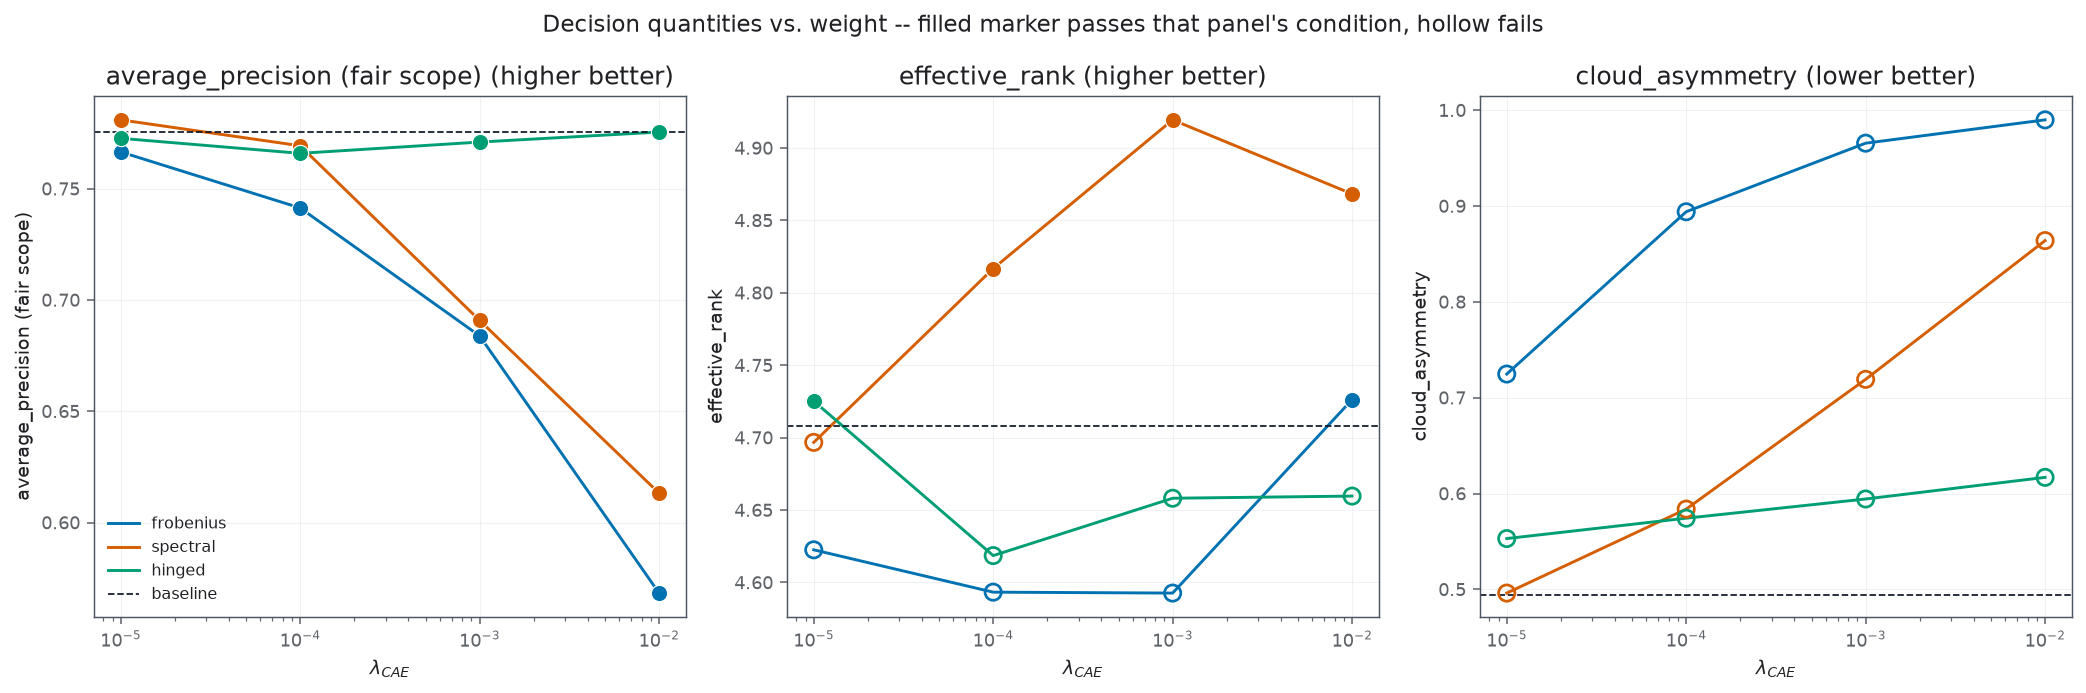

In [4]:
sweep_panels = [
    ("average_precision", "average_precision (fair scope)", False),
    ("effective_rank", "effective_rank", False),
    ("cloud_asymmetry", "cloud_asymmetry", True),
]

figure, axes = plt.subplots(1, 3, figsize=(15.0, 5.0), dpi=theme.figure_dpi)
for axis, (column, ylabel, lower_is_better) in zip(axes, sweep_panels):
    baseline_value = {
        "average_precision": baseline_average_precision,
        "effective_rank": baseline_effective_rank,
        "cloud_asymmetry": baseline_cloud_asymmetry,
    }[column]
    ok_column = {"effective_rank": "effective_rank_ok", "cloud_asymmetry": "cloud_asymmetry_ok"}.get(column)
    for metric in PENALTY_METRICS:
        subset = decision_frame[decision_frame.penalty_metric == metric].sort_values("weight")
        axis.plot(subset["weight"], subset[column], color=METRIC_COLOR[metric], linewidth=1.5, zorder=2, label=metric)
        passes = subset[ok_column] if ok_column else pd.Series(True, index=subset.index)
        axis.scatter(
            subset.loc[passes, "weight"], subset.loc[passes, column],
            color=METRIC_COLOR[metric], edgecolor="white", linewidth=0.6, s=70, zorder=3,
        )
        axis.scatter(
            subset.loc[~passes, "weight"], subset.loc[~passes, column],
            facecolor="none", edgecolor=METRIC_COLOR[metric], linewidth=1.4, s=70, zorder=3,
        )
    axis.axhline(baseline_value, color=theme.baseline_color, linestyle=theme.baseline_line_style, linewidth=theme.reference_line_width, label="baseline")
    axis.set_xscale("log")
    axis.set(xlabel=r"$\lambda_{CAE}$", ylabel=ylabel, title=f"{ylabel}{' (lower better)' if lower_is_better else ' (higher better)'}")
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
axes[0].legend(fontsize=8, frameon=theme.legend_frame)
figure.suptitle("Decision quantities vs. weight -- filled marker passes that panel's condition, hollow fails", fontsize=12)
figure.tight_layout()

## Prediction vs. geometry scatter

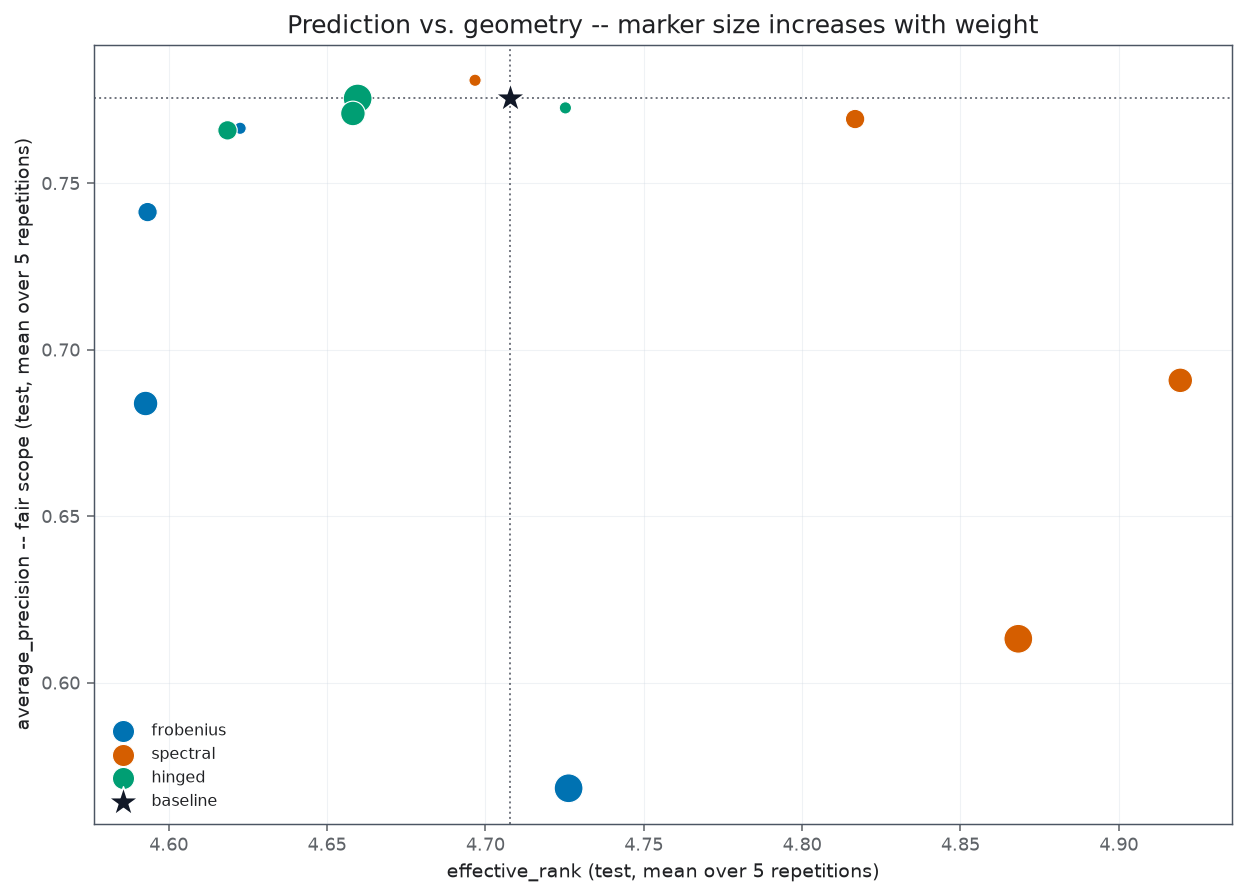

In [5]:
figure, ax = plt.subplots(figsize=(9.0, 6.5), dpi=theme.figure_dpi)
weight_marker_size = {weight: 40 + 60 * index for index, weight in enumerate(WEIGHTS)}
for metric in PENALTY_METRICS:
    subset = decision_frame[decision_frame.penalty_metric == metric]
    ax.scatter(
        subset["effective_rank"], subset["average_precision"],
        s=[weight_marker_size[w] for w in subset["weight"]],
        color=METRIC_COLOR[metric], label=metric, edgecolor="white", linewidth=0.6, zorder=3,
    )
ax.scatter(
    [baseline_effective_rank], [baseline_average_precision], marker="*", s=260,
    color=theme.baseline_color, edgecolor="white", linewidth=0.8, label="baseline", zorder=4,
)
ax.axhline(baseline_average_precision, color=theme.baseline_color, linestyle=":", linewidth=1, alpha=0.6)
ax.axvline(baseline_effective_rank, color=theme.baseline_color, linestyle=":", linewidth=1, alpha=0.6)
ax.set(
    xlabel="effective_rank (test, mean over 5 repetitions)",
    ylabel="average_precision -- fair scope (test, mean over 5 repetitions)",
    title="Prediction vs. geometry -- marker size increases with weight",
)
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()

## Verdict

In [6]:
winners = decision_frame[decision_frame.winner_candidate]
if len(winners) > 0:
    best = winners.iloc[0]
    print(
        f"Winner candidate: penalty_metric={best.penalty_metric!r}, weight={best.weight:g} -- "
        f"average_precision {best.average_precision:.4f} (baseline {baseline_average_precision:.4f}, "
        f"gain {best.average_precision_gain:+.4f}); effective_rank {best.effective_rank:.3f} "
        f"(baseline {baseline_effective_rank:.3f}); cloud_asymmetry {best.cloud_asymmetry:.3f} "
        f"(baseline {baseline_cloud_asymmetry:.3f})."
    )
    print(f"{len(winners)}/{len(decision_frame)} cells passed both conditions -- see decision_frame for the full ranking.")
else:
    print(
        "No (penalty_metric, weight) cell beat the baseline on average_precision while also "
        "keeping effective_rank/cloud_asymmetry at least as good. Negative result: the base "
        "combination for further head-loss comparisons remains the no-contractive baseline."
    )

No (penalty_metric, weight) cell beat the baseline on average_precision while also keeping effective_rank/cloud_asymmetry at least as good. Negative result: the base combination for further head-loss comparisons remains the no-contractive baseline.


## Closing notes

- **Formal result: negative.** No `(penalty_metric, weight)` cell passes both conditions —
  `cloud_asymmetry_ok` is `False` for all 12 cells. Baseline `cloud_asymmetry` is 0.494; even
  the best sweep cell (`spectral`@1e-5, 0.496) sits fractionally above it. Under the strict
  criterion, the base combination for further head-loss comparisons stays the no-contractive
  baseline.
- **But the near-miss is worth flagging, not discarding.** `spectral`@1e-5's `cloud_asymmetry`
  gap (0.496 vs. 0.494, +0.002) is a single point-estimate comparison with no seed-error-bar
  margin built into `winner_candidate` — this is almost certainly inside seed noise, not a
  real collapse. It is also the cell with the **best average_precision of the entire sweep**
  (0.781, +0.0053 over baseline, the only positive `average_precision_gain` in the table) and
  a competitive `effective_rank` (4.697 vs. baseline 4.708). `effective_rank` overall barely
  moves anywhere in the sweep (4.59–4.92 across all 12 cells, baseline 4.71) — it is not the
  quantity driving this result; `cloud_asymmetry` is.
- **`cloud_asymmetry` is the real story, and it reproduces `part_2`'s weight-sensitivity
  finding exactly**: `frobenius` and `spectral` both climb sharply and near-monotonically
  with weight (`frobenius` 0.72 -> 0.99, `spectral` 0.50 -> 0.86), while `hinged` stays in a
  narrow band (0.55 -> 0.62) far below either — consistent with `part_1`'s finding that
  `hinged` decouples prediction quality from weight, now shown to do the same for geometric
  collapse. At every weight *except* the lowest, `hinged`'s `cloud_asymmetry` beats both
  `frobenius` and `spectral` outright; `spectral`@1e-5 (0.496) is the single sweep cell that
  undercuts `hinged`'s entire range (0.553–0.617), which is exactly why it is the only
  near-miss on the baseline.
- **Practical reading**: if a single next step is wanted, `spectral` at low weight
  (1e-5, and worth also trying `5e-6`/`1e-6` to see whether `cloud_asymmetry` drops further
  below baseline while `average_precision` holds) is the most promising candidate on this
  evidence, not `hinged` — despite `hinged` being the more *robust* metric across the weight
  range tested. This is a genuine tension the point-estimate criterion does not resolve:
  "best at its best setting" (`spectral`) vs. "most stable across settings" (`hinged`).
- **Caveat carried over from `part_1`/`part_2`**: this run used a 15% deterministic pixel
  subsample of both `train` and `test` (not the full split), applied for wall-clock reasons
  after the per-model decode cost was diagnosed as the actual bottleneck (`part_1`'s
  methodology cell). The fair-scope class count at this subsample (455/508) falls short of
  `part_0`'s full-split 508/508 — re-running at a larger fraction (or the full split, now
  that decoding is materialized once rather than per-model) would tighten this comparison,
  particularly for the near-miss `cloud_asymmetry` reading above.
